<a href="https://colab.research.google.com/github/Anna15-del/Task-Two/blob/main/MICROPROJECT_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset path: /kaggle/input/face-mask-dataset


In [ ]:
import os

print(os.listdir(path))
dataset_path = os.path.join(path, "data")
print(os.listdir(dataset_path))

['data']
['without_mask', 'with_mask']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
data = []
labels = []

categories = ["with_mask", "without_mask"]

for category in categories:

    folder = os.path.join(dataset_path, category)
    label = categories.index(category)

    for img in os.listdir(folder):

        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image,(128,128))

        data.append(image)
        labels.append(label)

data = np.array(data)/255.0
labels = np.array(labels)

print("Total images:", len(data))

Total images: 7553


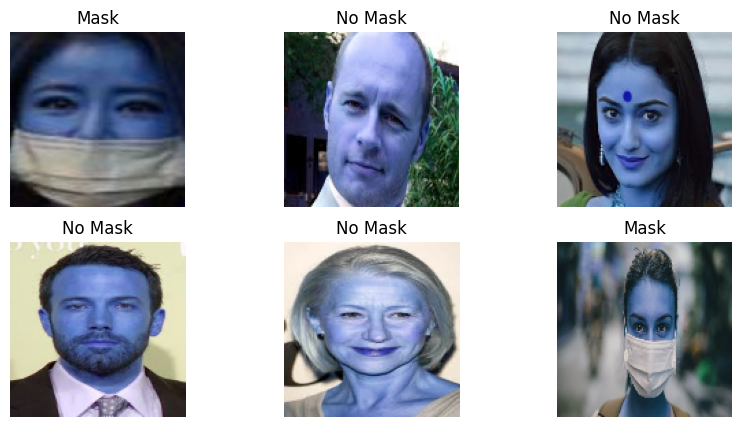

In [ ]:
plt.figure(figsize=(10,5))

for i in range(6):

    index = random.randint(0,len(data)-1)

    plt.subplot(2,3,i+1)
    plt.imshow(data[index])

    if labels[index] == 0:
        plt.title("Mask")
    else:
        plt.title("No Mask")

    plt.axis("off")

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train,2)
y_test = to_categorical(y_test,2)

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test),
    batch_size=32
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.7670 - loss: 0.5252 - val_accuracy: 0.8663 - val_loss: 0.3531
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9032 - loss: 0.2347 - val_accuracy: 0.9246 - val_loss: 0.1900
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9359 - loss: 0.1739 - val_accuracy: 0.9312 - val_loss: 0.1819
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9521 - loss: 0.1367 - val_accuracy: 0.9345 - val_loss: 0.1706
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9697 - loss: 0.0941 - val_accuracy: 0.9411 - val_loss: 0.1780
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9717 - loss: 0.0879 - val_accuracy: 0.9444 - val_loss: 0.1731
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9802 - loss: 0.0583 - val_accuracy: 0.9444 - val_loss: 0.1952
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9877 - loss: 0.0321 - val_acc

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9231 - loss: 0.4761
Test Accuracy: 0.9278623461723328
Test Loss: 0.44179031252861023


48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


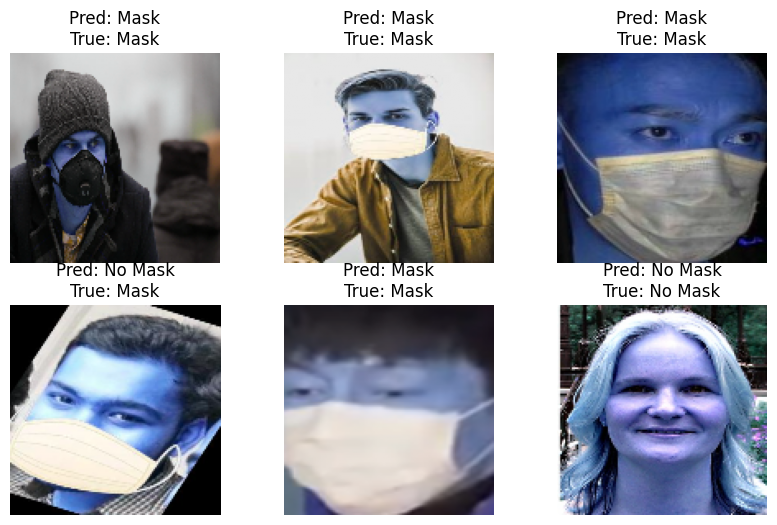

In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

classes = ["Mask","No Mask"]

plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_test[i]

    predicted_label = classes[predicted_labels[i]]
    true_label = classes[true_labels[i]]

    plt.imshow(img)
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis("off")

plt.show()